In [1]:
from matplotlib.colors import ListedColormap
import torch
import nrrd 
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models 
from torch.utils.data import Dataset,DataLoader
from model.LeNet5 import LeNet
import numpy as np
import os
from PIL import Image, ImageOps
from torchvision import transforms
from pathlib import Path
from typing import Dict, Optional
import re
from torch.utils.data import random_split
from collections import Counter
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
import wandb
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
#Global variable
pattern=re.compile(r"^Segment(\d+)_Tags$")
Segment_signal_string="Segmentation.Status:inprogress"
label_type={'binh_thuong':0,
            'dut_ban_phan_1_3_giua':1,
            'dut_hoan_toan_1_3_giua':2,
            'dut_ban_phan_1_3_duoi':3,
            'dut_hoan_toan_1_3_duoi':4,
            'dut_hoan_toan_1_3_tren':5,
            'dut_ban_phan_1_3_tren':6
            }

Scanning folder: 2025_14_11_Thanh
Number of selected files: 19
Scanning folder: 2025_22_11_Thuan
Number of selected files: 20
Scanning folder: 2026_18_1_Thuan
Number of selected files: 16
Scanning folder: 2026_1_2_Thanh
Number of selected files: 20
Scanning folder: 26_01_02_Thanh
Number of selected files: 22
Scanning folder: 26_16_02_Thuan
Number of selected files: 52
Scanning folder: 26_27_02_Thanh
Number of selected files: 20

ACL type distribution:
Total patient: 169
dut_ban_phan_1_3_giua: 30
dut_hoan_toan_1_3_giua: 29
dut_ban_phan_1_3_duoi: 17
dut_hoan_toan_1_3_tren: 32
dut_ban_phan_1_3_tren: 21
binh_thuong: 37
segment_1: 3


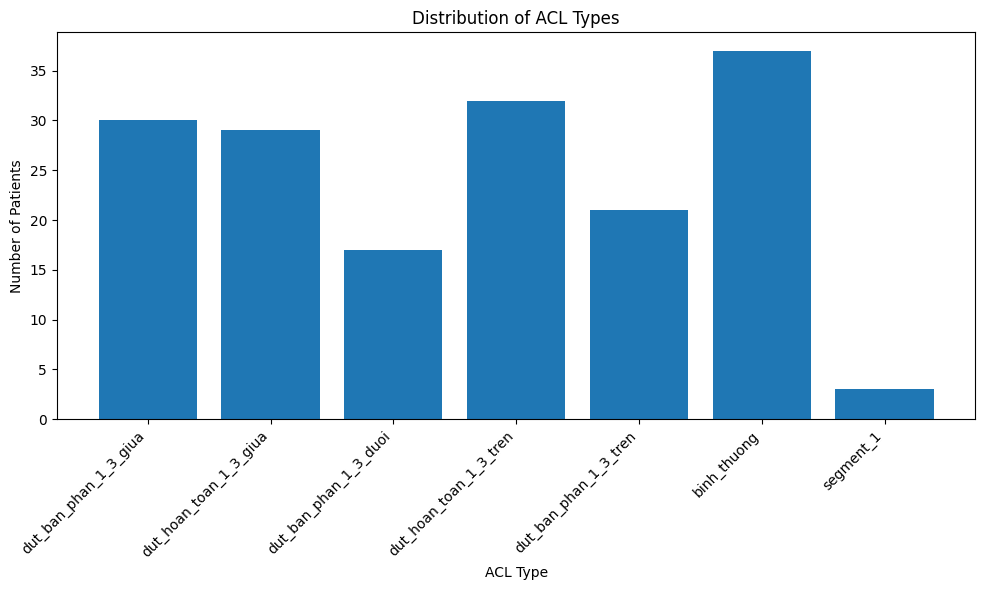

In [3]:


class ACLDataCollector:
    def __init__(
        self,
        root_dir: str,
        pattern: str,
        segment_signal_string: str,
        image_keyword: str = "t2_tse_sag",
        seg_keyword: str = "Segmentation*.seg.nrrd",
    ):
        self.root_dir = Path(root_dir)
        self.pattern = re.compile(pattern)
        self.segment_signal_string = segment_signal_string
        self.image_keyword = image_keyword.lower()
        self.seg_keyword = seg_keyword
        self.all_patients: Dict[str, Dict] = {}
        self.type_count: Dict[str, int] = {}

    def get_acl_indices(self, seg_header: dict):
        seg_indices = []
        for k in seg_header.keys():
            m = self.pattern.match(k)
            if m:
                seg_indices.append(m.group(1))
        return seg_indices

    def get_acl_type(self, seg_header: Dict) -> Optional[str]:
        indices = self.get_acl_indices(seg_header)
        for idx in indices:
            tag_key = f"Segment{idx}_Tags"
            name_key = f"Segment{idx}_Name"

            if tag_key in seg_header and name_key in seg_header:
                value = str(seg_header[tag_key])
                if value.startswith(self.segment_signal_string):
                    return str(seg_header[name_key]).lower()
        return None

    def collect_data_and_seg(self, folder_path: Path) -> Dict:
        result = {}
        for subfolder in folder_path.iterdir():
            if not subfolder.is_dir():
                continue
            seg_files = sorted(subfolder.glob(self.seg_keyword))
            t2_files = sorted(
                p for p in subfolder.glob("*.nrrd")
                if self.image_keyword in p.stem.lower()
            )
            if not seg_files or not t2_files:
                continue
            _, seg_header = nrrd.read(str(seg_files[0]))
            acl_type = self.get_acl_type(seg_header)

            result[subfolder.name] = {
                "nrrd": str(t2_files[0]),
                "seg": str(seg_files[0]),
                "type": acl_type,
            }
        return result
    def collect_all(self) -> Dict:
        self.all_patients = {}
        for sub_folder in self.root_dir.iterdir():
            if not sub_folder.is_dir():
                continue
            print(f"Scanning folder: {sub_folder.name}")
            data_dict = self.collect_data_and_seg(sub_folder)
            self.all_patients.update(data_dict)
            print(f"Number of selected files: {len(data_dict)}")

        return self.all_patients

    def count_acl_types(self) -> Dict[str, int]:
        self.type_count = {}
        for _, data in self.all_patients.items():
            acl_type = data["type"] if data["type"] is not None else "unknown"
            self.type_count[acl_type] = self.type_count.get(acl_type, 0) + 1
        return self.type_count

    def print_summary(self):
        if not self.type_count:
            self.count_acl_types()
        print("\nACL type distribution:")
        print(f"Total patient: {len(self.all_patients)}")
        for k, v in self.type_count.items():
            print(f"{k}: {v}")

    def plot_distribution(self):
        if not self.type_count:
            self.count_acl_types()

        labels = list(self.type_count.keys())
        counts = list(self.type_count.values())

        plt.figure(figsize=(10, 6))
        plt.bar(labels, counts)
        plt.xlabel("ACL Type")
        plt.ylabel("Number of Patients")
        plt.title("Distribution of ACL Types")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":

    collector = ACLDataCollector(
        root_dir=r"D:\Project\ACL\my_tool\data",
        pattern=pattern,
        segment_signal_string=Segment_signal_string
    )

    all_patients=collector.collect_all()
    collector.count_acl_types()
    collector.print_summary()
    collector.plot_distribution()

In [4]:
class MRI_data(Dataset):
    def __init__(
        self,
        data_dict: Dict,
        img_trasform=None,
        label_transform=None,
        target_size=(320,320),
        target_depth=25
    ):
        self.data_dict = data_dict
        self.img_transform = img_trasform
        self.label_transform = label_transform
        self.target_size = target_size
        self.target_depth = target_depth

        self.samples = []
        num_patient = 0

        for patient, data in data_dict.items():
            nrrd_path = data['nrrd']
            seg_path = data['seg']

            nrrd_data, _ = nrrd.read(nrrd_path)
            seg_data, _ = nrrd.read(seg_path)

            type_acl = data['type']

            if type_acl == 'segment_1':
                print("Skipping segment_1 label")
                continue

            if nrrd_data.shape != seg_data.shape:
                print(f"Mismatch shape for {patient}: image={nrrd_data.shape}, seg={seg_data.shape}")
                continue

            self.samples.append((nrrd_data, label_type[type_acl]))
            num_patient += 1

        print(f"Number of patient selected / total: {num_patient}/{len(data_dict)}")

    def __len__(self):
        return len(self.samples)

    def fix_depth(self, volume):
        """
        volume shape = (H,W,D)
        """
        H, W, D = volume.shape

        if D > self.target_depth:
            start = (D - self.target_depth) // 2
            volume = volume[:, :, start:start + self.target_depth]

        elif D < self.target_depth:
            pad = self.target_depth - D
            pad_before = pad // 2
            pad_after = pad - pad_before

            volume = np.pad(
                volume,
                ((0,0),(0,0),(pad_before,pad_after)),
                mode="constant"
            )

        return volume

    def __getitem__(self, index):

        img, label = self.samples[index]

        # normalize
        img = img / (np.max(img) + 1e-8)

        # fix slice depth
        img = self.fix_depth(img)

        # convert to tensor
        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)  # (D,H,W)
        img = img.unsqueeze(0)  # (1,D,H,W)

        label = torch.tensor(label, dtype=torch.long)

        if self.img_transform:
            img = self.img_transform(img)

        if self.label_transform:
            label = self.label_transform(label)

        return img, label

In [5]:
img_transform=transforms.Compose([
    transforms.CenterCrop((320,320)),
])
dataset=MRI_data(data_dict=all_patients,img_trasform=img_transform)

Mismatch shape for Cai Kim Loc_25210566: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Le Thi Thuy_25193052: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Le Van Chung_25938957: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Nguyen Hoang Gia Tuan_20250616: image=(608, 608, 25), seg=(512, 512, 29)
Mismatch shape for Nguyen Huu Nghia_25246508: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Nguyen Minh Luan_24281378: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Nguyen Ngoc Dang Duong_20250529 (loi ve): image=(608, 608, 25), seg=(512, 512, 29)
Mismatch shape for Nguyen Ngoc Long_20250911: image=(352, 352, 23), seg=(320, 320, 27)
Mismatch shape for Nguyen Thi Yen_25209300: image=(608, 608, 25), seg=(512, 512, 29)
Mismatch shape for Nguyen Thien An_25194729: image=(608, 608, 25), seg=(512, 512, 29)
Mismatch shape for Pham Anh Duc_25180208: image=(352, 352, 25), seg=(512, 512, 29)
Mismatch shape for Pham Minh Sang_20250714: 

In [6]:
print(f"Dataset length: {len(dataset)}")
print(f"Sample image shape: {dataset[39][0].shape}, Sample label: {dataset[39][1]}")

Dataset length: 120
Sample image shape: torch.Size([1, 25, 320, 320]), Sample label: 1


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MRI_3D_CNN(nn.Module):
    def __init__(self, num_classes: int = 3, in_channels: int = 1):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv3d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),   # [D,H,W] -> [D/2,H/2,W/2]

            # Block 2
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),

            # Make output size fixed regardless of input spatial size
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),              # [B,128,1,1,1] -> [B,128]
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """
        x shape: [B, C, D, H, W]
        """
        x = self.features(x)
        x = self.classifier(x)
        return x

In [8]:
model = MRI_3D_CNN(num_classes=len(label_type), in_channels=1)
print(model)

MRI_3D_CNN(
  (features): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (13): BatchNorm3

In [9]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 96
Validation set size: 24


Overall Dataset Label Distribution:


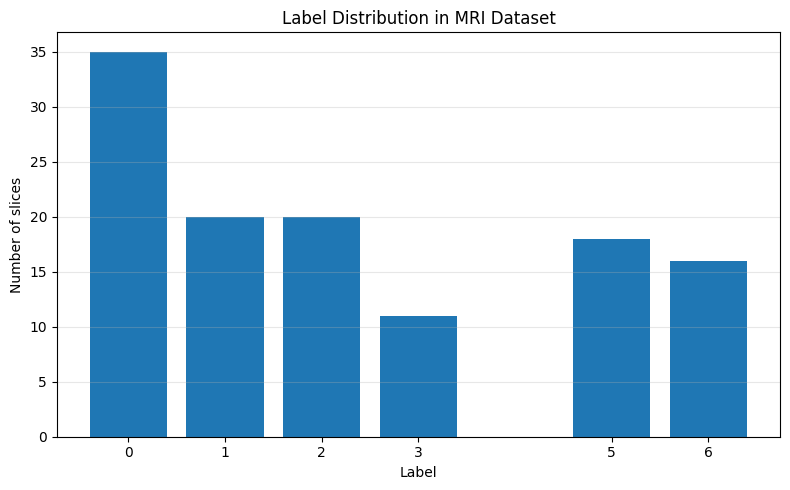

Label 0: 35 samples
Label 1: 20 samples
Label 2: 20 samples
Label 3: 11 samples
Label 5: 18 samples
Label 6: 16 samples
Training Set Label Distribution:


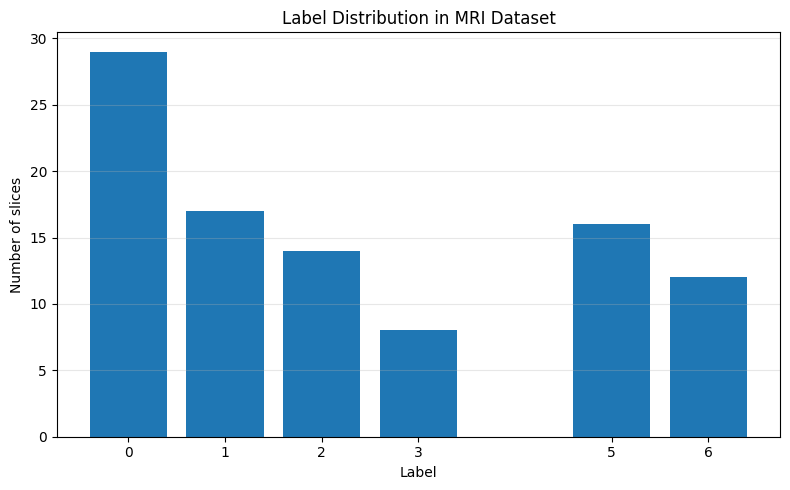

Label 0: 29 samples
Label 1: 17 samples
Label 2: 14 samples
Label 3: 8 samples
Label 5: 16 samples
Label 6: 12 samples
Validation Set Label Distribution:


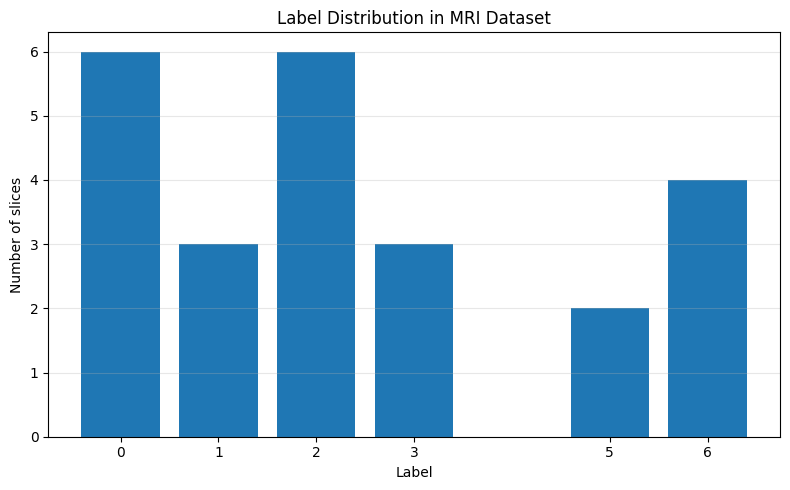

Label 0: 6 samples
Label 1: 3 samples
Label 2: 6 samples
Label 3: 3 samples
Label 5: 2 samples
Label 6: 4 samples


In [10]:
def plot_label_distribution(dataset):
    labels = []
    for _, label in dataset:
        # handle torch tensor labels
        if isinstance(label, torch.Tensor):
            label = label.item()
        labels.append(label)
    label_counts = Counter(labels)
    # sort by label index
    labels_sorted = sorted(label_counts.keys())
    counts_sorted = [label_counts[l] for l in labels_sorted]
    plt.figure(figsize=(8, 5))
    plt.bar(labels_sorted, counts_sorted)
    plt.xlabel("Label")
    plt.ylabel("Number of slices")
    plt.title("Label Distribution in MRI Dataset")
    plt.xticks(labels_sorted)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    # also print counts
    for l in labels_sorted:
        print(f"Label {l}: {label_counts[l]} samples")
# Plot label distribution for the entire dataset, training set, and validation set
print("Overall Dataset Label Distribution:")
plot_label_distribution(dataset)
print("Training Set Label Distribution:")
plot_label_distribution(train_dataset)
print("Validation Set Label Distribution:")
plot_label_distribution(val_dataset)

In [11]:
train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=16,shuffle=True)

In [12]:
wandb.login()

wandb: Currently logged in as: baymaxnguyen306 (baymaxnguyen306-ho-chi-minh-city-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [13]:
class TrainerWB: 
    def __init__(self,config,train_loader,val_loader,model): 
        self.config=config
        self.device=torch.device('cuda' if torch.cuda.is_available() else'cpu')
        self.epochs=config.epoch
        self.learning_rate=config.lr
        self.batch_size=config.batch_size

        self.train_loader=train_loader
        self.val_loader=val_loader

        self.model=model.to(self.device)
        
        self.criterion=nn.CrossEntropyLoss()
        self.optimizer=self.optim_build()


    def optim_build(self): 
        if self.config['optim']=='SGD': 
            return optim.SGD(self.model.parameters(), lr=self.learning_rate, momentum=0.9) 
        elif self.config['optim']=='Adam': 
            return optim.Adam(self.model.parameters(), lr=self.learning_rate) 
        else: 
            raise ValueError("Unsupported optimizer type") 
    def train(self): 
        self.model.train()
        running_loss=0.0 
        correct=0
        total=0 
        loop=tqdm(self.train_loader,desc='Tao dang training',leave=False) 
        for image, label in loop: 
            image,label= image.to(self.device), label.to(self.device) 
            #Forward propagation: 
            output=self.model(image) 
            loss=self.criterion(output,label) 
            #backward propagation 
            self.optimizer.zero_grad() 
            loss.backward() 
            self.optimizer.step() 
            #Metrics calculation 
            running_loss += loss.item()*image.size(0) 
            preds=torch.argmax(output,dim=1) 
            correct += (preds==label).sum().item() 
            total += label.size(0)
             #Update progress bar 
            loop.set_postfix(loss=running_loss/ (total/self.batch_size), accuracy=100.* correct/ total) 
        avg_loss = running_loss / total 
        accuracy = correct / total 
        return avg_loss, accuracy 
    def validate(self): 
        self.model.eval() 
        running_loss = 0.0 
        correct = 0 
        total = 0 

        all_preds = []
        all_labels = []

        with torch.no_grad(): 
            for images, labels in self.val_loader: 
                images, labels = images.to(self.device), labels.to(self.device) 

                outputs = self.model(images) 
                loss = self.criterion(outputs, labels) 
                running_loss += loss.item() * images.size(0) 
                preds = torch.argmax(outputs, dim=1) 

                correct += (preds == labels).sum().item() 
                total += labels.size(0)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_loss = running_loss / total 
        accuracy = correct / total 

        cm = confusion_matrix(all_labels, all_preds)

        return avg_loss, accuracy, cm
    def fit(self): 
        for epoch in range(self.epochs): 

            train_loss, train_acc = self.train() 
            val_loss, val_acc, cm = self.validate() 

            if epoch % 5 == 0:
                print(f"\nEpoch [{epoch+1}/{self.epochs}]")
                print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
                print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
                print("\nConfusion Matrix:")
                print(cm)
            wandb.log({
                "Train Loss": train_loss,
                "Train Accuracy": train_acc,
                "Validation Loss": val_loss,
                "Validation Accuracy": val_acc
            })
        print("Training complete.")

In [14]:
def main():
    with wandb.init(project="ACL_Classification_3D_CNN", reinit=True):
        trainer = TrainerWB(
            config=wandb.config,
            train_loader=train_loader,
            val_loader=val_loader,
            model=model
        )
        trainer.fit()

In [15]:
sweep_config={
    'method':'random',
    'metric':{
        'name':'Validation Accuracy',
        'goal':'maximize'
    },
    'parameters':{
        'lr':{
            'values':[0.01,0.001,0.0001]
        },
        'epoch':{
            'values':[20,30,40]
        },
        'batch_size':{
            'values':[2,4,8,16]
        },
        'optim':{
            'values':['SGD']
        },
        'architecture':{
            'values':['cnn1','cnn2']
        }
    }
}


In [ ]:
sweep_id= wandb.sweep(sweep_config, project="ACL_Classification_3D_CNN")
wandb.agent(sweep_id, function=main, count=10)

Create sweep with ID: zzxa8wwv
Sweep URL: https://wandb.ai/baymaxnguyen306-ho-chi-minh-city-university-of-technology/ACL_Classification_3D_CNN/sweeps/zzxa8wwv


wandb: Agent Starting Run: f9vyv8fi with config:
wandb: 	architecture: cnn2
wandb: 	batch_size: 16
wandb: 	epoch: 30
wandb: 	lr: 0.01
wandb: 	optim: SGD


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



Epoch [1/30]
Train Loss: 1.9670, Train Acc: 0.1250
Val Loss: 1.9447, Val Acc: 0.1667

Confusion Matrix:
[[0 0 0 0 0 6]
 [0 0 0 0 0 3]
 [0 0 0 0 0 6]
 [0 0 0 0 0 3]
 [0 0 0 0 0 2]
 [0 0 0 0 0 4]]



Epoch [6/30]
Train Loss: 1.6987, Train Acc: 0.3125
Val Loss: 1.8593, Val Acc: 0.2500

Confusion Matrix:
[[0 0 6 0 0 0]
 [0 0 3 0 0 0]
 [0 0 6 0 0 0]
 [0 0 3 0 0 0]
 [0 0 2 0 0 0]
 [0 0 4 0 0 0]]



Epoch [11/30]
Train Loss: 1.6019, Train Acc: 0.3854
Val Loss: 1.9042, Val Acc: 0.2083

Confusion Matrix:
[[5 0 0 0 0 1]
 [3 0 0 0 0 0]
 [4 0 0 0 0 2]
 [3 0 0 0 0 0]
 [2 0 0 0 0 0]
 [4 0 0 0 0 0]]



Epoch [16/30]
Train Loss: 1.5312, Train Acc: 0.3750
Val Loss: 1.9905, Val Acc: 0.0417

Confusion Matrix:
[[1 1 2 0 0 2]
 [2 0 1 0 0 0]
 [3 0 0 0 0 3]
 [1 0 1 0 0 1]
 [2 0 0 0 0 0]
 [3 0 0 0 1 0]]


Tao dang training:  50%|█████     | 3/6 [01:02<01:02, 20.89s/it, accuracy=45.8, loss=23.8]